In [136]:
import torch
import psutil
import torch.nn.functional as F
import matplotlib.pyplot  as plt
%matplotlib inline

In [137]:
def get_smart_device():
    # 1. Check if CUDA is available at all
    if not torch.cuda.is_available():
        print("CUDA not available. Using CPU.")
        return torch.device('cpu')
    
    # 2. Check power source via psutil
    battery = psutil.sensors_battery()
    
    # If a battery is detected and the power cable is NOT plugged in
    if battery is not None and not battery.power_plugged:
        print(f"⚠️ Battery detected ({battery.percent}%). Switching to CPU to avoid GPU power-throttling.")
        return torch.device('cpu')
    
    # 3. Cable plugged in -> Use GPU
    gpu_name = torch.cuda.get_device_name(0)
    print(f"⚡ Plugged in! Using GPU: {gpu_name}")
    return torch.device('cuda')


In [138]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [139]:
len(words)

32033

In [140]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [141]:
# create dataset

block_size = 3 # context length
X, Y = [],[]
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix] #crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [142]:
# build dataset

def build_dataset(words):
    block_size = 3 # context length
    X, Y = [],[]
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix] #crop and append

    if device == 'cuda':
        X = torch.tensor(X).to('cuda')
        Y = torch.tensor(Y).to('cuda')
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    print(X.shape, Y.shape)
    return X, Y

import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [143]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [144]:
C = torch.randn((27,2))

In [145]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [146]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [147]:
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)
# torch.cat(torch.unbind(emb, 1),1)

h = torch.tanh(emb.view(-1,6) @ W1 + b1)

In [148]:
h.shape

torch.Size([228146, 100])

In [149]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [150]:
logits = h @ W2 + b2

In [151]:
logits.shape

torch.Size([228146, 27])

In [152]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

In [153]:
probs[0].sum()

tensor(1.0000)

In [154]:
# -probs[torch.arange(32), Y].log().mean()

In [155]:
# more linear

In [156]:
##Dataset
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [157]:
## parameters

device = get_smart_device()

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27,10), generator=g, device=device)
W1 = torch.randn((30, 190), generator=g, device=device)
b1 = torch.randn(190, generator=g, device=device)
W2 = torch.randn((190, 27), generator=g, device=device)
b2 = torch.randn(27, generator=g, device=device)

parameters = [C, W1, b1, W2, b2]

⚠️ Battery detected (72.84%). Switching to CPU to avoid GPU power-throttling.


In [158]:
sum(p.nelement() for p in parameters)

11317

In [159]:
for p in parameters:
    p.requires_grad = True

In [160]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [161]:
lri = []
lossi = []
stepi = []

In [162]:
# forward pass
# train split, dev/validation split, test split
# 80%, 10%, 10%

for i in range(200000):
    
    # mini bathing
    ix = torch.randint(0, Xtr.shape[0], (512,))
    
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) # 32, 100
    logits = h @ W2 + b2 # 32, 27
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdims=True)
    # loss = -probs[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass

    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 50000 else 0.05 if i < 100000 else 0.01  
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
        
# print(loss.item())


In [163]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # 32, 200
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1512, grad_fn=<NllLossBackward0>)

In [164]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # 32, 200
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1844, grad_fn=<NllLossBackward0>)

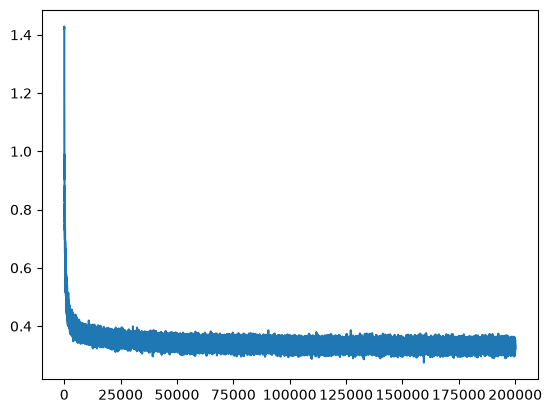

In [165]:
plt.plot(stepi, lossi)

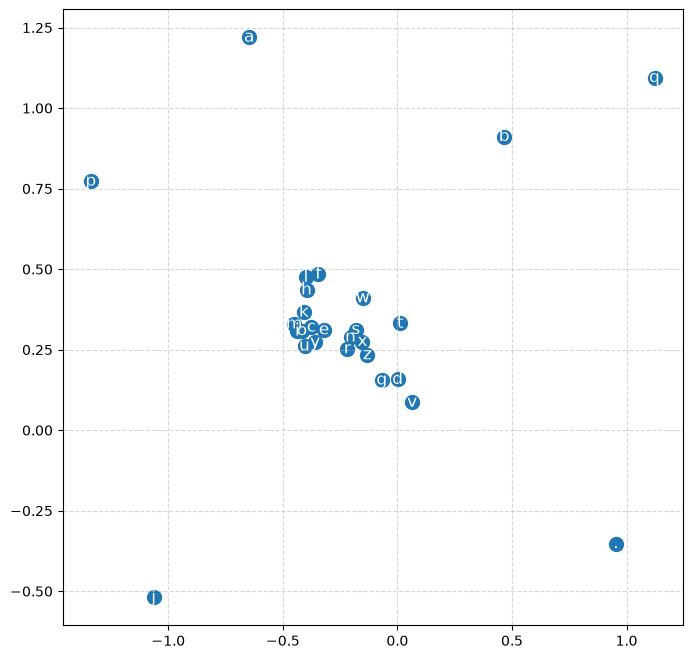

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(C[:, 0].detach().cpu(), C[:, 1].detach().cpu(), s=100)

for i in range(C.shape[0]):
    plt.text(
        C[i, 0].item(), 
        C[i, 1].item(), 
        itos[i], 
        ha="center", 
        va="center", 
        color="white", 
        fontsize=12
    )

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [170]:
# sampling

g = torch.Generator(device=device).manual_seed(2147483647)
for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
        
    print(''.join(itos[i] for i in out))

derie.
mogh.
makilah.
tyha.
konish.
tainella.
kaman.
a.
samiyah.
javer.
goton.
molie.
cavo.
keyah.
aren.
emia.
sadeu.
tiaviyn.
ryslspir.
camellor.
